# Funciones, Derivadas y Gradientes

## 1. Introducción

### ¿Qué es una función?

Una función es una relación que asigna a cada elemento de un conjunto de entrada un único elemento de un conjunto de salida. Formalmente, puede expresarse como:

$$
f: X \rightarrow Y
$$

donde cada elemento $x \in X$ se asocia con un valor $f(x) \in Y$.

- $X$ es el conjunto de entrada (también llamado dominio).
- $Y$ es el conjunto de salida (también llamado codominio).

Para cada elemento $x$ que pertenece al conjunto $X$, la función $f$ le asigna exactamente un valor en el conjunto $Y$. Ese valor se escribe como $f(x)$.

De manera intuitiva, una función puede entenderse como una regla que transforma una entrada en una salida. Por ejemplo:

$$
f(x) = x^2
$$

Esta función toma un valor numérico y devuelve su cuadrado. Aunque este ejemplo es simple, el mismo principio se aplica a funciones mucho más complejas.


### Funciones en Machine Learning

En Machine Learning, las funciones aparecen en dos niveles fundamentales:

Por un lado, un modelo puede interpretarse como una función que transforma datos de entrada en predicciones:

$$ 
\hat{y} = f(x; \theta)
$$

donde $x$ representa los datos de entrada, $\theta$ los parámetros del modelo y $\hat{y}$ la salida o predicción.

Por otro lado, para evaluar qué tan bien funciona el modelo, se define una función de costo:

$$
\mathcal{L}(\theta)
$$

Esta función mide el error entre las predicciones del modelo y los valores reales. El objetivo del entrenamiento es encontrar los parámetros que minimizan dicha función:

$$
\theta^* = \arg\min_{\theta} \mathcal{L}(\theta)
$$


### El problema fundamental

Esto nos lleva al problema central: *dada una función, ¿cómo podemos encontrar los valores que la minimizan?* Es decir, encontrar el valor o conjunto de valores (la entrada) que produce el resultado más pequeño posible de esa función (la salida).

En funciones simples, como $f(x) = x^2$, el mínimo es evidente. Sin embargo, en escenarios reales:

- Las funciones pueden depender de múltiples variables  
- No es posible visualizarlas directamente  
- Su comportamiento puede ser complejo  

Por lo tanto, no podemos depender únicamente de la intuición visual.

### Hacia derivadas y gradientes

Para poder encontrar mínimos de forma sistemática, necesitamos entender cómo cambia una función en un punto dado.

En particular, queremos responder preguntas como:

- ¿Qué ocurre si modificamos ligeramente la entrada?  
- ¿La función aumenta o disminuye?  
- ¿Qué tan rápido ocurre ese cambio?  

Responder estas preguntas requiere una herramienta que permita cuantificar el cambio local de una función. La derivada proporciona una medida precisa de cómo cambia una función en un punto. En una dimensión, este cambio se interpreta como la pendiente de la función. Cuando extendemos esta idea a funciones de múltiples variables, aparece el concepto de gradiente, que permite describir el cambio en espacios de mayor dimensión.

En esta notebook nos centraremos en construir estos conceptos desde cero, tanto desde una perspectiva intuitiva como computacional.

## 2. Exploración de funciones simples

Antes de introducir herramientas formales como la derivada, es fundamental desarrollar una intuición clara sobre cómo se comportan las funciones. En esta sección trabajaremos con funciones simples de una variable, con el objetivo de entender visual y conceptualmente qué significa que una función “tenga un mínimo”. Esta intuición será la base sobre la cual construiremos todo lo demás.

### Funciones simples como punto de partida

Consideremos la siguiente función:

$$
f(x) = x^2
$$

Esta es una de las funciones más simples y, al mismo tiempo, más importantes en matemáticas. Su gráfica corresponde a una parábola abierta hacia arriba.

Si representamos esta función en un intervalo, por ejemplo $x \in [-5, 5]$, observamos lo siguiente:

- A medida que $x$ se aleja de $0$, el valor de la función crece  
- En $x = 0$, la función alcanza su valor más bajo posible  
- La función es simétrica respecto al eje vertical  

Este punto $x = 0$ se conoce como el **mínimo global** de la función.

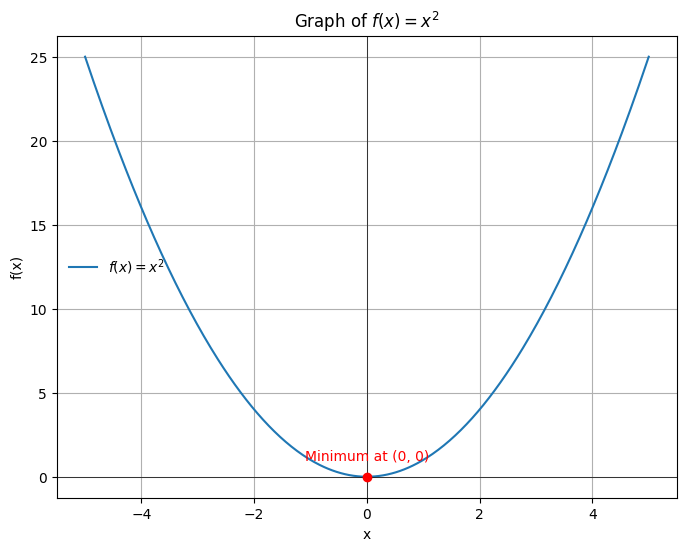

In [18]:
import numpy as np
import matplotlib.pyplot as plt

# Define the function f(x) = x^2
def f(x):
    return x**2

# Generate x values from -5 to 5
x = np.linspace(-5, 5, 400)
y = f(x)  # Compute y values

# Plot the function
plt.figure(figsize=(8, 6))
plt.plot(x, y, label=r'$f(x) = x^2$')  # Plot parabola
plt.scatter(0, f(0), color='red', zorder=5)          # Mark minimum point
plt.text(0, f(0) + 1, 'Minimum at (0, 0)', ha='center', color='red')  # Add label

# Add titles and axis labels
plt.title('Graph of $f(x) = x^2$')
plt.xlabel('x')
plt.ylabel('f(x)')

# Add grid and legend
plt.grid(True)
plt.legend(loc=6, frameon=False)

# Draw axis lines
plt.axhline(0, color='black', linewidth=0.5)
plt.axvline(0, color='black', linewidth=0.5)

plt.show()


### Desplazamiento de funciones

Ahora consideremos una variante:

$$
f(x) = (x - 2)^2
$$

Esta función tiene exactamente la misma forma que $x^2$, pero está desplazada horizontalmente.

Al graficarla, observamos que:

- La forma parabólica se conserva  
- El punto más bajo ya no está en $x = 0$, sino en $x = 2$  
- El valor mínimo sigue siendo $0$, pero ocurre en una posición distinta  

Este ejemplo es importante porque muestra que la forma de una función determina su comportamiento, pero sus parámetros determinan dónde ocurren los puntos clave.  

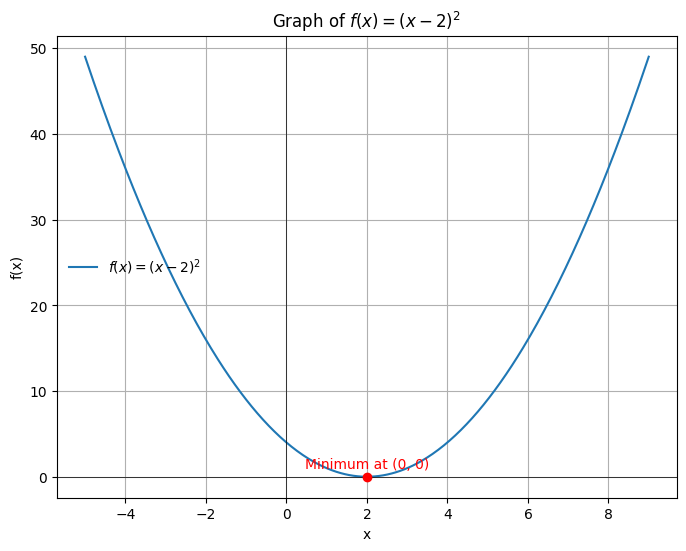

In [17]:
# Define the function f(x) = x^2
def f(x):
    return (x-2)**2

# Generate x values from -5 to 9
x = np.linspace(-5, 9, 400)
y = f(x)  # Compute y values

# Plot the function
plt.figure(figsize=(8, 6))
plt.plot(x, y, label=r'$f(x) = (x-2)^2$')  # Plot parabola
plt.scatter(2, f(2), color='red', zorder=5)          # Mark minimum point
plt.text(2, f(2) + 1, 'Minimum at (0, 0)', ha='center', color='red')  # Add label

# Add titles and axis labels
plt.title('Graph of $f(x) = (x-2)^2$')
plt.xlabel('x')
plt.ylabel('f(x)')

# Add grid and legend
plt.grid(True)
plt.legend(loc=6, frameon=False)

# Draw axis lines
plt.axhline(0, color='black', linewidth=0.5)
plt.axvline(0, color='black', linewidth=0.5)

plt.show()

### Funciones sin mínimo claro

No todas las funciones tienen un mínimo global bien definido. Consideremos:

$$
f(x) = x^3
$$

Al graficar esta función, observamos que:

- La función decrece cuando $x < 0$  
- La función crece cuando $x > 0$  
- No existe un punto que pueda identificarse como el más bajo o el más alto  

Sin embargo, hay algo interesante en $x = 0$:

- La pendiente cambia de negativa a positiva  
- La función “se aplana” momentáneamente  

Este tipo de punto no es un mínimo ni un máximo, pero será relevante más adelante cuando estudiemos derivadas.

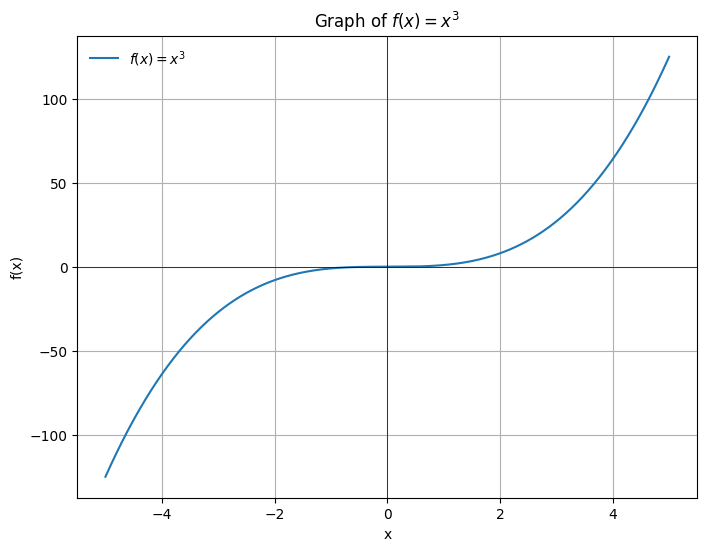

In [20]:
# Define the function f(x) = x^3
def f(x):
    return x**3

# Generate x values from -5 to 5
x = np.linspace(-5, 5, 400)
y = f(x)  # Compute y values

# Plot the function
plt.figure(figsize=(8, 6))
plt.plot(x, y, label=r'$f(x) = x^3$')  # Plot parabola

# Add titles and axis labels
plt.title('Graph of $f(x) = x^3$')
plt.xlabel('x')
plt.ylabel('f(x)')

# Add grid and legend
plt.grid(True)
plt.legend(loc=2, frameon=False)

# Draw axis lines
plt.axhline(0, color='black', linewidth=0.5)
plt.axvline(0, color='black', linewidth=0.5)

plt.show()


### Indentificar el mínimo de una función

Desde una perspectiva visual, identificar un mínimo es sencillo:

- Es el punto donde la función alcanza su valor más bajo  
- Si nos movemos ligeramente hacia la izquierda o derecha, el valor de la función aumenta  

Formalmente, un punto $x^*$ es un mínimo global de la función $f$ si el valor de la función en $x^*$ es menor o igual que el valor de la función en cualquier otro punto $x$ del dominio.

$$
f(x^*) \leq f(x) \quad \forall x
$$

En términos más intuitivos:

*Un mínimo es un punto desde el cual cualquier pequeño movimiento incrementa el valor de la función.*

Podemos interpretar esto de forma geométrica:

- Imaginemos la gráfica como una superficie.
- Un mínimo corresponde al punto más bajo accesible.
- Si colocamos una esfera en ese punto, no tendría hacia dónde rodar hacia abajo.

Esta interpretación será especialmente útil cuando pasemos a funciones en múltiples dimensiones.

En Machine Learning, cuando entrenamos un modelo, buscamos los parámetros $\theta^*$ que minimizan la función de costo $\mathcal{L}(\theta)$.  Es decir, el error en $\theta^*$ es menor o igual que en cualquier otro conjunto de parámetros.

$$
L(\theta^*) \leq L(\theta) \quad \forall x
$$

En lugar de buscar el mínimo de una función matemática simple, buscamos el mínimo de la función de costo respecto a los parámetros del modelo:

- La función representa la función de costo $\mathcal{L}(\theta)$.
- El mínimo global es el conjunto de parámetros $(\theta^*)$ que hacen que el error sea lo mas pequeño posible. En ese punto, el modelo tiene el mejor desempeño posible porque el error es mínimo.
- El entrenamiento busca exctamente ese punto: el mínimo global de la función de costo.
- Si la función no es convexa (como en redes neuronales profundas), podemos encontrar mínimos locales, pero la idea es la misma: **buscar parámetros que reduzcan el error.**

### El problema que queda abierto

Hasta este punto, podemos identificar un mínimo si vemos la función. Pero, *¿cómo encontramos ese mínimo sin poder visualizar la función?*

En problemas reales, las funciones de costo pueden depender de cientos o miles de variables:

$$
\mathcal{L}(\theta_1, \theta_2, \dots, \theta_n)
$$

En estos casos, la visualización directa deja de ser una opción.

Para resolver este problema, necesitamos una forma de analizar el comportamiento de la función en un punto específico, sin depender de su gráfica completa.

En particular, necesitamos responder:

- ¿La función está aumentando o disminuyendo en este punto?  
- ¿Qué tan rápido cambia?  
- ¿Qué ocurre si nos movemos ligeramente?  

Estas preguntas nos llevan directamente al concepto de derivada, como herramienta que permite medir el cambio local de una función. A diferencia de la inspección visual, la derivada proporciona una forma precisa, general y computable de analizar funciones, incluso cuando no pueden ser visualizadas.

## 3. Derivada

Hasta ahora hemos visto que es posible identificar mínimos observando una función. Sin embargo, este enfoque depende completamente de la visualización, lo cual no es viable en problemas reales. Para avanzar, necesitamos una herramienta que nos permita analizar **cómo cambia una función en un punto específico**, sin necesidad de ver toda su forma. Esa herramienta es la derivada.

### La idea fundamental: medir el cambio local

Supongamos que tenemos una función $f(x)$ y un punto específico $x$.

Queremos responder a la siguiente pregunta: Si nos movemos ligeramente desde $x$, ¿cómo cambia el valor de la función?

Una primera aproximación sería medir el cambio promedio entre dos puntos:

$$
\frac{f(x + h) - f(x)}{h}
$$

donde $h$ es un pequeño desplazamiento.

Esta expresión representa la **tasa de cambio promedio** entre $x$ y $x + h$.

Sin embargo, lo que realmente nos interesa es el comportamiento **exactamente en el punto $x$**, no en un intervalo, es decir, *la tasa de cambio instantánea*. Para obtener esto, hacemos que $h$ sea cada vez más pequeño, hasta aproximarnos al límite:

$$
f'(x) = \lim_{h \to 0} \frac{f(x + h) - f(x)}{h}
$$

Esta expresión define la **derivada** de la función en el punto $x$.

### Interpretación geométrica

Podemos interpretar la derivada desde una perspectiva geométrica:

- La función puede verse como una curva.
- En cada punto de la curva, podemos trazar una recta tangente.
- La pendiente de esa recta es la derivada en ese punto.  
- Entonces, la derivada puede interpretarse como la pendiente de la recta tangente a la función en un punto $x$.

Si imaginamos que estamos “caminando” sobre la curva, como si fuera un paisaje en una montaña:

- El signo de la derivada (positivo o negativo) nos indica hacía donde vamos:

    - Si $f'(x) > 0$, estamos subiendo.
    - Si $f'(x) < 0$, estamos bajando.
    - Si $f'(x) = 0$, el terreno es localmente plano: no subimos ni bajamos (posible mínimo, máximo o meseta).

- La magnitud de la derivada $|f'(x)|$ nos indica qué tan inclinada es la superficie en ese punto:

    - Un valor grande indica una pendiente pronunciada (cambio rápido).
    - Un valor pequeño indica una pendiente suave (cambio lento).

En conjunto, la derivada nos proporciona dos tipos de información clave:

- **Dirección del cambio** (crecer o decrecer).
- **Intensidad del cambio** (qué tan rápido ocurre).

Por ejemplo, para la función:

$$
f(x) = x^2
$$

su derivada es:

$$
f'(x) = 2x
$$

La derivada mide como cómo cambia $f(x)$ cuando $x$ varía en una cantidad infinitesimal. Evaluando en distintos puntos:

- En $x = -2$,  $f'(x) = -4$ → → La tasa de cambio instantánea es −4, la función decrece localmente.
- En $x = 0$,  $f'(x) = 0$ → La tasa de cambio instantánea es 0, la función es localmente plana.
- En $x = 2$,  $f'(x) = 4$ → La tasa de cambio instantánea es 4, la función crece localmente.

Esto coincide con lo que observamos visualmente en la gráfica.



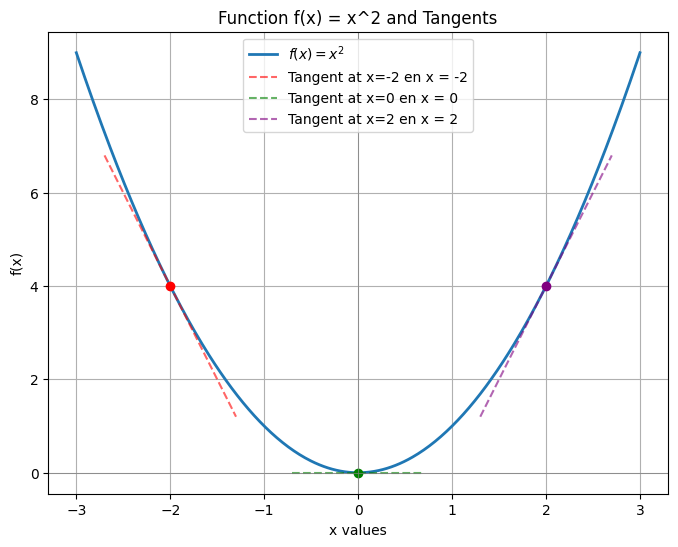

In [54]:
# Define the function and its derivative
def f(x):
    return x**2

def df(x):
    return 2*x

# Points where we want to draw tangents
x_points = [-2, 0, 2]
colors = ['red', 'green', 'purple']
labels = ['Tangent at x=-2', 'Tangent at x=0', 'Tangent at x=2']

# Create x values for the main curve
x_vals = np.linspace(-3, 3, 400)
y_vals = f(x_vals)

# Plot the function
plt.figure(figsize=(8, 6))
plt.plot(x_vals, y_vals, label=r'$f(x) = x^2$', linewidth=2)

# Plot tangents at specified points
for x0, color, label in zip(x_points, colors, labels):
    y0 = f(x0)
    slope = df(x0)
    tangent_x = np.linspace(x0 - 0.7, x0 + 0.7, 100)
    tangent_y = slope * (tangent_x - x0) + y0
    plt.plot(tangent_x, tangent_y, color=color, linestyle='--', alpha=0.6, label=f'{label} en x = {x0}')
    plt.plot(x0, y0, 'o', color=color)

# Add labels and legend
plt.title('Function f(x) = x^2 and Tangents')
plt.xlabel('x values')
plt.ylabel('f(x)')
plt.axhline(0, color='gray', linewidth=0.5)
plt.axvline(0, color='gray', linewidth=0.5)
plt.legend()
plt.grid(True)
#plt.tight_layout()

plt.show()


### Derivada como información local

Un aspecto clave de la derivada que hemos mencionado, es que proporciona información **local**, no global.

Esto significa que:

- No describe toda la función ni su comportamiento completo.
- Solo indica cómo se comporta en un entorno inmediato del punto considerado.

Por ejemplo, cuando evaluamos la derivada en un punto específico, solo sabemos si la función
está creciendo, decreciendo o está momentáneamente plana en ese punto, pero no sabemos aún
si ese punto corresponde a un mínimo, un máximo o simplemente una región plana.

Esta naturaleza local es precisamente lo que hace a la derivada tan útil en **optimización**.
En lugar de conocer toda la función, basta con saber cómo cambia en el punto actual para decidir
hacia dónde movernos y reducir su valor.

Sin embargo, esta misma propiedad implica que debemos analizar con cuidado los puntos donde
la derivada es cero, ya que la información local por sí sola no siempre es suficiente para
determinar si hemos alcanzado un mínimo.


### Derivada y puntos críticos

La derivada de una función mide su pendiente, es decir, indica la dirección y la rapidez con la que cambia el valor de la función.

- Si la derivada es **negativa**, la función está *decreciendo*.
- Si la derivada es **positiva**, la función está *creciendo*.

Un mínimo ocurre exactamente en el punto donde la función deja de decrecer y comienza a crecer.

#### Comportamiento alrededor de un mínimo

Analicemos qué sucede alrededor de un mínimo local $x$:

- Antes de $x$:  

  $$f'(x) < 0 \quad \Rightarrow \quad \text{la función decrece}$$

- En $x$:  

  $$f'(x) = 0 \quad \Rightarrow \quad \text{pendiente horizontal}$$

- Después de $x$:  

  $$f'(x) > 0 \quad \Rightarrow \quad \text{la función crece}$$

Esto explica por qué los puntos donde la derivada es cero son **candidatos a mínimos**:

$$
f'(x) = 0
$$

A estos puntos se les denomina **puntos críticos**.

#### Punto crítico ≠ mínimo garantizado

Es fundamental notar que una derivada igual a cero no garantiza que el punto sea un mínimo.

Un punto crítico puede corresponder a:

1. Un mínimo local
2. Un máximo local
3. Un punto de inflexión, donde la derivada es cero pero la función no cambia de decreciente a creciente

**Ejemplos intuitivos**

- $f(x) = x^2$  
  - $f'(x) = 2x$  
  - $f'(0) = 0 \Rightarrow \quad \text{Mínimo}$  

- $f(x) = -x^2$  
  - $f'(x) = -2x$  
  - $f'(0) = 0 \Rightarrow \quad \text{Máximo}$  

- $f(x) = x^3$  
  - $f'(x) = 3x^2$  
  - $f'(0) = 0 \Rightarrow \quad \text{Punto de inflexión}$  

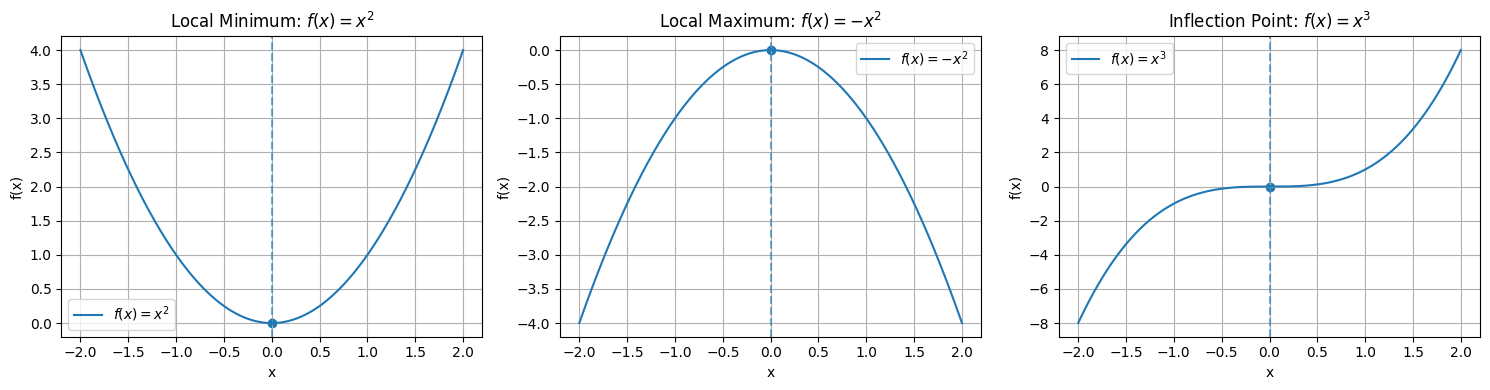

In [ ]:
# Define functions
def f_min(x):
    return x**2

def f_max(x):
    return -x**2

def f_inflection(x):
    return x**3

# Create x values
x = np.linspace(-2, 2, 400)

# Evaluate functions
y_min = f_min(x)
y_max = f_max(x)
y_inflect = f_inflection(x)

# Create subplots: 1 row, 3 columns
fig, axes = plt.subplots(1, 3, figsize=(15, 4))

# --- Plot 1: Local Minimum ---
axes[0].plot(x, y_min, label=r"$f(x) = x^2$")
axes[0].scatter(0, 0)
axes[0].axvline(0, linestyle="--", alpha=0.6)
axes[0].set_title(r"Local Minimum: $f(x) = x^2$")
axes[0].set_xlabel("x")
axes[0].set_ylabel("f(x)")
axes[0].legend()

# --- Plot 2: Local Maximum ---
axes[1].plot(x, y_max, label=r"$f(x) = -x^2$")
axes[1].scatter(0, 0)
axes[1].axvline(0, linestyle="--", alpha=0.6)
axes[1].set_title(r"Local Maximum: $f(x) = -x^2$")
axes[1].set_xlabel("x")
axes[1].set_ylabel("f(x)")
axes[1].legend()

# --- Plot 3: Inflection Point ---
axes[2].plot(x, y_inflect, label=r"$f(x) = x^3$")
axes[2].scatter(0, 0)
axes[2].axvline(0, linestyle="--", alpha=0.6)
axes[2].set_title(r"Inflection Point: $f(x) = x^3$")
axes[2].set_xlabel("x")
axes[2].set_ylabel("f(x)")
axes[2].legend()

# Enable grid on all subplots
for ax in axes:
    ax.grid(True)

# Adjust layout
plt.tight_layout()
plt.show()

#### Segunda derivada: cómo confirmar un mínimo

Para diferenciar estos casos utilizamos la segunda derivada, que describe la curvatura de la función.

El punto es un **mínimo local**:

- Si:  $f'(x) = 0 \quad \text{y} \quad f''(x) > 0$

Es un **máximo local**:

- Si:  $f''(x) < 0$

El criterio **no es concluyente**:

- Si:  $f''(x) = 0$

Intuición geométrica:

- $f''(x) > 0$: la función tiene forma de “U”
- $f''(x) < 0$: la función tiene forma de “∩”

#### Aplicación en Machine Learning

En Machine Learning, estas ideas se aplican a la función de costo $L(\theta)$ durante el proceso de entrenamiento de un modelo:

- La función de costo describe el “paisaje” del error del modelo, donde cada punto corresponde a un conjunto de parámetros $\theta$. El objetivo es encontrar los parámetros que minimicen $L(\theta)$


- La derivada (o gradiente, cuando hay multiples parámetros) mide la tasa de cambio instantánea del error respecto a los parámetros.  
- Igual que en la interpretación geométrica, el signo indica la dirección en la que el error aumenta o disminuye, mientras que su magnitud refleja qué tan pronunciado es ese cambio.  
    - La derivada (o gradiente) indica la dirección de mayor incremento.
    - Para minimizar, se avanza en la dirección opuesta.   
- Los algoritmos de optimización, como *Gradient Descent*, usan esta información para ajustar los parámetros en la dirección que reduce el error, explorando el paisaje de la función de costo en busca de mínimos. Sin embargo:  
    - No todos los puntos donde el gradiente es cero son soluciones óptimas.
    - En espacios de alta dimensión aparecen mínimos locales, máximos y puntos silla (regiones planas del espacio de búsqueda).
    - Este tipo de algortimos buscan puntos donde el gradiente sea cercano a cero con la esperanza de converger a un mínimo adecuado.

El objetivo del entrenamiento es **minimizar la función de costo**, que mide el error del modelo
para un conjunto dado de parámetros. En Machine Learning, la derivada se convierte en una **brújula** que guía el entrenamiento del modelo: indica cómo ajustar los parámetros para reducir el error y avanzar hacia un mínimo de la función de costo.





## 4. Derivadas numéricas.

### ¿Por qué necesitamos la derivada numérica?

En la sección anterior definimos la derivada como un límite:

$$
f'(x) = \lim_{h \to 0} \frac{f(x + h) - f(x)}{h}
$$

Esta definición es rigurosa desde el punto de vista matemático, pero plantea un problema inmediato cuando queremos llevarla a la práctica: No podemos evaluar el límite $h \to 0$ de forma exacta en una computadora.

Además, en muchos casos reales, ni siquiera disponemos de la expresión analítica de la derivada. Esto ocurre con frecuencia cuando:

- La función es demasiado compleja  
- La función está definida de forma implícita  
- Solo tenemos acceso a evaluaciones de la función (como una “caja negra”)  

En este contexto, depender de derivadas analíticas no es viable.

**De la teoría a la computación**

Si observamos la definición de derivada, notamos que está construida a partir de una idea simple:

- Evaluar la función en puntos cercanos  
- Medir cómo cambia  
- Normalizar ese cambio  

La única parte que no podemos replicar exactamente es el límite cuando $h \to 0$.

Sin embargo, sí podemos elegir un valor pequeño de $h$ y aproximar la derivada utilizando ese valor. Esto nos permite transformar una definición teórica en un procedimiento computacional.


### Idea central: aproximar el cambio

La idea central de la derivada numérica consiste en utilizar la definición de la derivada, pero reemplazando el límite por un valor pequeño y finito de $h$. En lugar de hacer que $h \to 0$, medimos directamente cómo cambia la función al realizar pequeños desplazamientos en la entrada.

En este contexto, la derivada deja de verse como un objeto puramente teórico y se convierte en una medición práctica del cambio local.

- **Diferencia hacia adelante**

Una primera aproximación consiste en observar cómo cambia la función al movernos ligeramente hacia adelante desde un punto $x$:

$$
f'(x) \approx \frac{f(x + h) - f(x)}{h}
$$

Esta expresión estima la pendiente utilizando solo un punto adicional, es sencilla de implementar y captura la idea básica de tasa de cambio.

Sin embargo, tiene una limitación importante:
- solo utiliza información de un lado del punto $x$, lo que introduce un sesgo en la estimación de la pendiente.

Como resultado, esta aproximación puede ser menos precisa, especialmente cuando $h$ no es extremadamente pequeño.

- **Diferencia central**

Una mejor aproximación consiste en medir el cambio de la función a ambos lados del punto de interés:

$$
f'(x) \approx \frac{f(x + h) - f(x - h)}{2h}
$$

Esta expresión es más precisa porque considera el comportamiento de la función de forma simétrica alrededor del punto de interés.

Intuitivamente:
- $f(x + h)$ indica hacia dónde va la función.
- $f(x - h)$ indica de dónde viene.
- La derivada se obtiene como un promedio del cambio en ambas direcciones.

Esta simetría reduce el sesgo y produce una aproximación más estable del comportamiento local de la función. En la práctica, esta será la aproximación que utilizaremos.

### Implementación de la derivada numérica (desde 0)


A continuación, implementamos la derivada numérica utilizando la aproximación por diferencia central, ya que proporciona un buen equilibrio entre simplicidad y precisión:

$$
f'(x) \approx \frac{f(x + h) - f(x - h)}{2h}
$$

La implementación es directa, definimos una función que reciba:

- $f$, la función que queremos derivar
- $x$, el punto donde evaluamos la derivada
- $h$, un valor pequeño que controla la precisión

In [ ]:
# Numerical approximation of the derivative using central difference formula
def numerical_derivative(f, x, h=1e-5):
    return (f(x + h) - f(x - h)) / (2 * h)

Esta implementación refleja directamente la definición intuitiva de la derivada numérica: evaluar la función, movernos ligeramente y observar el cambio:

- $f(x+h)$ evalúa la función ligeramente a la derecha de $x$
- $f(x-h)$ evalúa la función ligeramente a la izquierda.
- La resta mide el cambio total entre ambos puntos.
- La división por $2h$ normaliza ese cambio para obtener una tasa.

Esta función no require conocer la forma análitica de la derivada, lo cual la hace completamente general

**Ejemplo de uso:**

Consideremos la función:

$$
f(x)=x^2
$$

El valor obtenido representa una aproximación de la pendiente de la función en $x = 3$.


In [ ]:
# Define the original function
def f(x):
    return x**2

# Point where the derivative will be evaluated
x = 3

# Compute the numerical derivative at x
numerical_derivative(f, x)

6.000000000039306

**Interpretación**

- No hemos usado reglas de derivación.
- Solo evaluamos la función en dos puntos cercanos.
- La derivada surge como una medida del cambio local.

Este enfoque es completamente general: funciona para cualquier función que pueda evaluarse, incluso si no conocemos su derivada analítica.

La derivada numérica muestra que derivar no es aplicar reglas, sino medir cómo cambia una función. Esta forma de pensar (medir el cambio a partir de evaluaciones) es la base computacional sobre la que se construyen los algoritmos de optimización en Machine Learning.

### Comparación con la derivada analítica

Para evaluar la calidad de la aproximación, comparemos la derivada numérica con la derivada analítica de la función conocida:

$$
f(x)=x^2
$$

Sabemos que su derivada analítica es:

$$
f'(x) = 2x
$$

Implementamos y evaluamos ambas derivadas en un punto concreto, $x=2$:

In [ ]:
# Define the original function
def f(x):
    return x**2

# Numerical approximation of the derivative using central differences
def numerical_derivative(f, x, h=1e-5):
    return (f(x + h) - f(x - h)) / (2 * h)

# Analytical derivative of the function
def analytical_derivative(x):
    return 2 * x

# Point where the derivative will be evaluated
x = 2

# Compute both numerical and analytical derivatives
num_der = numerical_derivative(f, x)
ana_der = analytical_derivative(x)

# Print results
print(f'Numerical derivative: {num_der}')
print(f'Analytical derivative: {ana_der}')

Numerical derivative: 4.000000000026205
Analytical derivative: 4


En la práctica, ambos valores serán muy cercanos, aunque no idénticos.

- La derivada analítica es exactamente $4$.
- La derivada numérica es una valor muy cercano a $4$

La diferencia entre ambos valores es pequeña y se debe a errores de aproximación. Esto confirma que la derivada numérica es una aproximación válidad del cambio local de una función.

**Comparación en distintos puntos**

Ahora compararemos ambos enfoques evaluando la derivada en varios valores de $x$. Esto permite verificar que la aproximación es consistente a lo largo del dominio.



In [47]:
xs = np.linspace(-5, 5, 10)

print(f"{'x':>6} | {'numerical':>10} | {'analytic':>10}")
print("-" * 32)

for x in xs:
    num_der = numerical_derivative(f, x)
    ana_der = analytical_derivative(x)
    print(f"{x:6.2f} | {num_der:10.4f} | {ana_der:10.4f}")


     x |  numerical |   analytic
--------------------------------
 -5.00 |   -10.0000 |   -10.0000
 -3.89 |    -7.7778 |    -7.7778
 -2.78 |    -5.5556 |    -5.5556
 -1.67 |    -3.3333 |    -3.3333
 -0.56 |    -1.1111 |    -1.1111
  0.56 |     1.1111 |     1.1111
  1.67 |     3.3333 |     3.3333
  2.78 |     5.5556 |     5.5556
  3.89 |     7.7778 |     7.7778
  5.00 |    10.0000 |    10.0000


### Interpretación del error

Al comparar la derivada numérica con la derivada analítica, es normal observar pequeñas diferencias entre ambas. Estas discrepancias no son un fallo del método, sino una consecuencia directa de cómo estamos aproximando el cambio. La derivada numérica introduce error porque estamos aproximando un concepto continuo (el límite) con un valor finito de $h$. 

Existen dos fuentes principales de error:

1. Error de aproximación

Proviene de usar un $h$ finito en lugar de un valor infinitesimal, esto implica que no estamos midiendo el cambio exacto en un punto, sino en un pequeño intervalo alrededor de ese punto.

Si $h$ es grande:
- El intervalo es amplio y la aproximación es poco precisa  
- La pendiente calculada refleja un cambio promedio, no local
- La aproximación se aleja de la derivada real

Cuanto más grande es $h$, peor es la aproximación al comportamiento local de la función. Este tipo de error se conoce como *error de truncamiento*

2. Error numérico

Las computadoras trabajan con precisión finita, lo que introduce errores adicionales cuando realizamos operaciones con números muy cercanos.

Si $h$ es muy pequeño:
- $f(x + h)$ y $f(x - h)$ se vuelven casi iguales  
- La resta entre ambos valores pierde precisión (cancelación numérica)

Este error es conocido como *error de redondeo*. Aunque teóricamente reducir $h$ mejora la aproximación, en la práctica, hacerlo demasiado pequeño puede empeorar el resultado.

Para observar este comportamiento, podemos evaluar la derivada para distintos valores de $h$:

In [65]:
x = 2

print(f"{'h':>10} | {'numerical derivative':>20}")
print("-" * 33)

for h in [1e-1, 1e-3, 1e-5, 1e-7, 1e-10]:
    num_der = numerical_derivative(f, x, h)
    print(f"{h:10.1e} | {num_der:20.20f}")


         h | numerical derivative
---------------------------------
   1.0e-01 | 4.00000000000000088818
   1.0e-03 | 3.99999999999955946350
   1.0e-05 | 4.00000000002620481609
   1.0e-07 | 3.99999999567413055956
   1.0e-10 | 4.00000033096148399636


Al ejecutar este código, se observa típicamente que:

- Para valores grandes de $h$, la aproximación es imprecisa.
- Al disminuir $h$, la aproximación mejora.
- Si $h$ es demasiado pequeño, pueden aparecer errores numéricos.

En la práctica, esto implica que existe un valor intermedio de $h$ que minimiza el error total: 

- No basta con hacer $h$ “lo más pequeño posible”  
- Es necesario elegir un valor adecuado empíricamente  
- Valores como $h = 10^{-5}$ suelen funcionar bien en muchos casos

La derivada numérica no es una medida exacta, sino una estimación basada en información local limitada. El error en la derivada numérica es una consecuencia natural de aproximar un concepto continuo en un entorno discreto. Esto refuerza la interpretación de la derivada como una aproximación del cambio instantáneo construida a partir de observaciones cercanas.

Entender estos conceptos permitirá:

- Interpretar correctamente los resultados.  
- Elegir mejores parámetros ($h$).
- Desarrollar intuición sobre métodos numéricos. 

Este tipo de razonamiento será fundamental cuando trabajemos con algoritmos de optimización en Machine Learning.

### Conexión con Machine Learning

Los conceptos desarrollados en esta sección constituyen el núcleo operativo del aprendizaje en Machine Learning.

En la práctica, entrenar un modelo equivale a resolver un problema de optimización:

$$
\theta^* = \arg\min_{\theta} \mathcal{L}(\theta)
$$

donde $\mathcal{L}(\theta)$ es la función de pérdida y $\theta$ representa los parámetros del modelo.

Para poder minimizar $\mathcal{L}(\theta)$, necesitamos responder una pregunta fundamental en cada paso del proceso: ¿Cómo cambia la función de pérdida si modificamos ligeramente los parámetros?

La derivada (y, en múltiples dimensiones, el gradiente) proporciona exactamente esa información. Indica:

- Si la función aumenta o disminuye al variar los parámetros  
- En qué dirección se produce el mayor incremento  
- Qué tan pronunciado es ese cambio  

Aunque en sistemas reales se utilizan derivadas analíticas o diferenciación automática, la idea subyacente es la misma que hemos implementado aquí:

- Evaluar la función en puntos cercanos  
- Estimar cómo cambia  
- Utilizar esa información para ajustar los parámetros  

De forma conceptual, el proceso de entrenamiento puede entenderse como una iteración del tipo:

$$
\theta \leftarrow \theta - \eta \cdot \nabla \mathcal{L}(\theta)
$$

donde $\theta$ representa los parámetros del modelo, $\nabla \mathcal{L}(\theta)$ es el gradiente de la función de pérdida respecto a esos parámetros, indicando en qué dirección la pérdida crece más rápido y $\eta$ es el learning rate (el tamaño del paso que damos en esa dirección).

El concepto de gradiente y su papel en el entrenamiento se retomará más adelante con mayor profundidad. Por ahora basta con entender que la derivada numérica ofrece una manera general de aproximar este gradiente cuando no se dispone de una expresión analítica.

A pesar de su valor conceptual, la derivada numérica no es la herramienta principal en Machine Learning moderno, por varias razones:

- Es costosa computacionalmente en espacios de alta dimensión  
- Requiere múltiples evaluaciones de la función por parámetro  
- Es sensible a errores numéricos  

Por estas razones, se prefieren métodos más eficientes como:

- Derivadas analíticas (cuando son manejables)  
- Diferenciación automática (por ejemplo, backpropagation en redes neuronales)  

Aun así, la derivada numérica cumple un papel fundamental en la comprensión del aprendizaje automático porque permite entender que:

- El aprendizaje se basa en medir cambios locales en una función. 
- No es necesario conocer la forma completa de la función para optimizarla. 
- Entrenar un modelo consiste en moverse dentro de una función utilizando información local sobre cómo cambia.
- La derivada numérica es la forma más simple y transparente de capturar esa información.